Original Dataset Shape: (4340, 8)


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner


Roll Number: 150096724005
Roll Number Mod 3: 0
Assigned Fuel Type: Petrol
More than 150 rows found.
No additional Petrol cars required.

Personalized Dataset Shape: (2123, 8)

========== DATA TYPES ==========
name             object
year              int64
selling_price     int64
km_driven         int64
fuel             object
seller_type      object
transmission     object
owner            object
dtype: object

========== MISSING VALUES ==========
name             0
year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
dtype: int64

========== DUPLICATE LISTINGS ==========
Number of duplicate rows: 406

========== STATISTICAL SUMMARY ==========


,year,selling_price,km_driven
count,2123.000000,2.123000e+03,2123.000000
mean,2012.595855,3.448401e+05,52340.079604
std,4.847011,3.636728e+05,38109.196219
min,1992.000000,2.000000e+04,101.000000
25%,2009.000000,1.500000e+05,25000.000000
50%,2014.000000,2.690000e+05,50000.000000
75%,2017.000000,4.500000e+05,70000.000000
max,2020.000000,8.900000e+06,806599.000000



Column: selling_price
Q1: 150000.0
Q3: 450000.0
IQR: 300000.0
Lower Bound: -300000.0
Upper Bound: 900000.0
Number of Outliers: 62

Column: km_driven
Q1: 25000.0
Q3: 70000.0
IQR: 45000.0
Lower Bound: -42500.0
Upper Bound: 137500.0
Number of Outliers: 28

Dataset shape after removing duplicates: (1717, 8)

Car age column created.


,year,car_age,selling_price
0,2007,19,60000
1,2007,19,135000
3,2017,9,250000
5,2007,19,140000
6,2016,10,550000


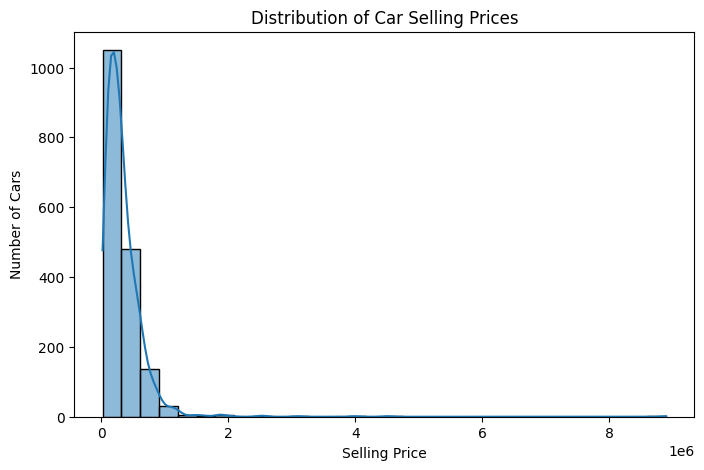

Insight:
The selling price distribution is right-skewed, with most cars having relatively lower prices and a smaller number of cars having very high prices.


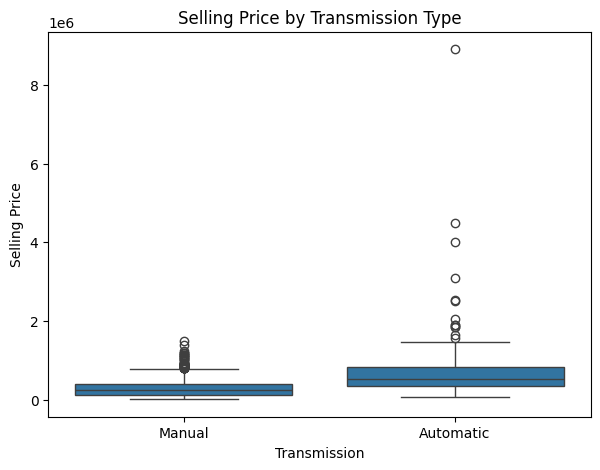

Insight:
Automatic cars generally have higher selling prices than manual cars, although there is variation within each group.


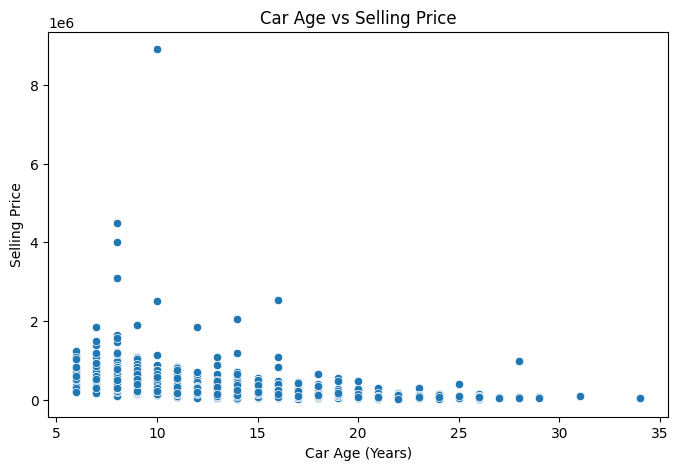

Insight:
Older cars generally have lower selling prices, showing a negative relationship between car age and resale value.


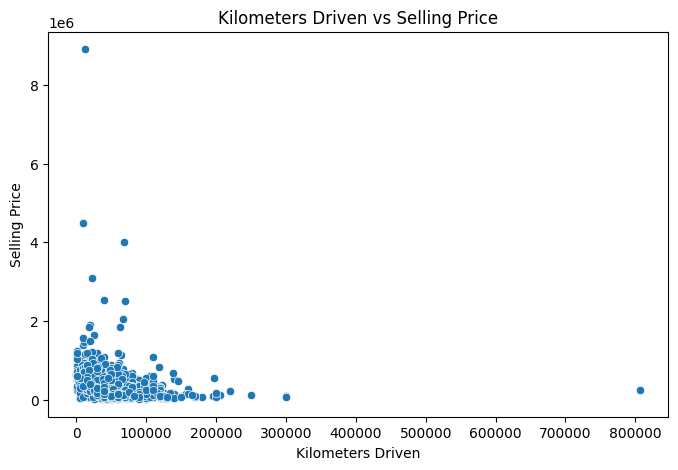

Insight:
Cars with higher kilometers driven generally have lower selling prices, although the relationship is not perfectly linear.


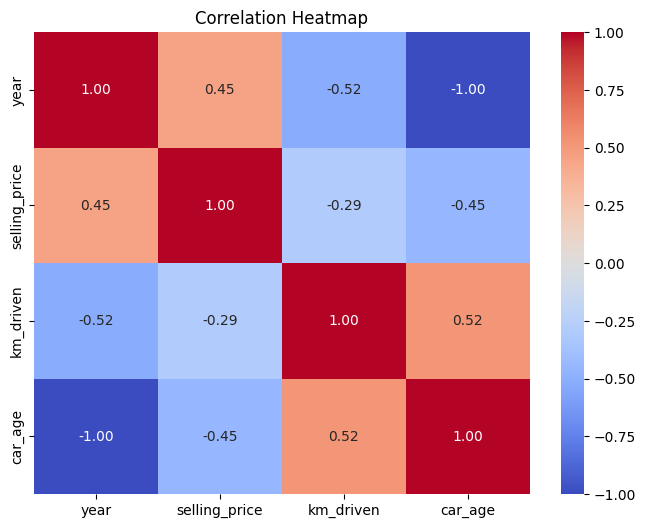

Insight:
Car age and kilometers driven generally have negative relationships with selling price, while the relationship between the numerical variables helps identify useful features for prediction.

Training samples: 1373
Testing samples: 344

========== BASELINE MODEL ==========
Train R²: 0.287
Test R²: 0.418
Test RMSE: 205096.02

========== IMPROVED MODEL ==========
Train R²: 0.277
Test R²: 0.385
Test RMSE: 210807.32

========== PASS CONDITION ==========
Pass condition not achieved yet.
Additional feature refinement may be required.


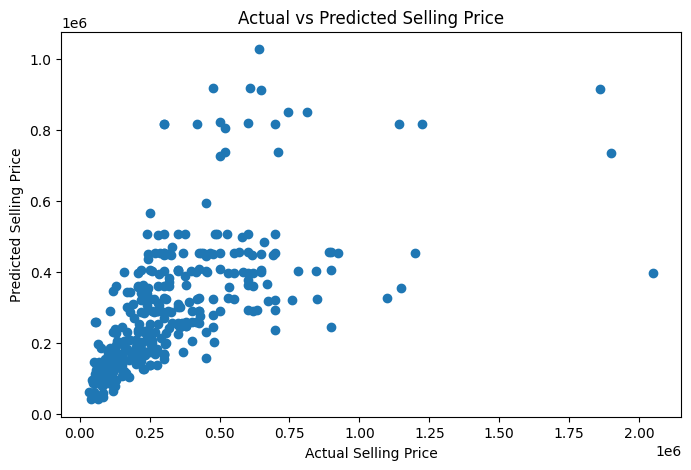


========== FINAL MODEL COMPARISON ==========
Baseline Model - Train R²: 0.287
Baseline Model - Test R²: 0.418
Baseline Model - Test RMSE: 205096.02

Log Model - Train R²: 0.277
Log Model - Test R²: 0.385
Log Model - Test RMSE: 210807.32

========== FINAL SUMMARY ==========

The personalized dataset contains 1717 cars.

The assigned fuel type was Petrol because the roll number
modulo 3 was 0.

Duplicate listings were removed and a car_age feature was
created from the year of manufacture.

Exploratory analysis showed that car age and kilometers driven
generally have a negative relationship with selling price.

A Linear Regression model was trained using an 80/20 train-test
split.

Baseline Test R²: 0.418
Baseline Test RMSE: 205096.02

Improved Test R²: 0.385
Improved Test RMSE: 210807.32

The log transformation was used because selling prices were
right-skewed.

The most important factors reducing resale value are generally
higher car age and higher kilometers driven.



In [8]:
# ============================================================
# MACHINE LEARNING FUNDAMENTALS
# Assignment 3: Used Car Price Prediction - CarDekho
# ============================================================


# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error


# ============================================================
# 2. LOAD DATASET
# ============================================================

df = pd.read_csv("CAR DETAILS FROM CAR DEKHO.csv")

print("Original Dataset Shape:", df.shape)

display(df.head())


# ============================================================
# 3. PERSONALIZE THE DATASET
# ============================================================

roll_number = 150096724005

fuel_class = roll_number % 3

print("Roll Number:", roll_number)
print("Roll Number Mod 3:", fuel_class)

# 0 = Petrol
# 1 = Diesel
# 2 = CNG/LPG/Electric

if fuel_class == 0:
    assigned_fuel = "Petrol"

elif fuel_class == 1:
    assigned_fuel = "Diesel"

else:
    assigned_fuel = ["CNG", "LPG", "Electric"]


print("Assigned Fuel Type:", assigned_fuel)


# Filter dataset
if isinstance(assigned_fuel, list):

    filtered_df = df[
        df["fuel"].isin(assigned_fuel)
    ].copy()

else:

    filtered_df = df[
        df["fuel"] == assigned_fuel
    ].copy()


# If fewer than 150 rows, add Petrol cars
if len(filtered_df) < 150:

    petrol_cars = df[
        df["fuel"] == "Petrol"
    ].copy()

    required = 150 - len(filtered_df)

    filtered_df = pd.concat([
        filtered_df,
        petrol_cars.head(required)
    ])

    print("Less than 150 rows.")
    print("Petrol cars were added.")

else:

    print("More than 150 rows found.")
    print("No additional Petrol cars required.")


print("\nPersonalized Dataset Shape:", filtered_df.shape)


# ============================================================
# 4. BASIC EDA
# ============================================================

print("\n========== DATA TYPES ==========")

print(filtered_df.dtypes)


print("\n========== MISSING VALUES ==========")

print(filtered_df.isnull().sum())


print("\n========== DUPLICATE LISTINGS ==========")

print(
    "Number of duplicate rows:",
    filtered_df.duplicated().sum()
)


print("\n========== STATISTICAL SUMMARY ==========")

display(filtered_df.describe())


# ============================================================
# 5. OUTLIER CHECK
# ============================================================

def check_outliers(data, column):

    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = data[
        (data[column] < lower_bound) |
        (data[column] > upper_bound)
    ]

    print("\nColumn:", column)
    print("Q1:", Q1)
    print("Q3:", Q3)
    print("IQR:", IQR)
    print("Lower Bound:", lower_bound)
    print("Upper Bound:", upper_bound)
    print("Number of Outliers:", len(outliers))

    return outliers


price_outliers = check_outliers(
    filtered_df,
    "selling_price"
)

km_outliers = check_outliers(
    filtered_df,
    "km_driven"
)


# ============================================================
# 6. REMOVE DUPLICATES
# ============================================================

filtered_df = filtered_df.drop_duplicates().copy()

print(
    "\nDataset shape after removing duplicates:",
    filtered_df.shape
)


# ============================================================
# 7. CREATE CAR AGE
# ============================================================

current_year = 2026

filtered_df["car_age"] = (
    current_year - filtered_df["year"]
)

print("\nCar age column created.")

display(
    filtered_df[
        ["year", "car_age", "selling_price"]
    ].head()
)


# ============================================================
# 8. PLOT 1 - PRICE DISTRIBUTION
# ============================================================

plt.figure(figsize=(8, 5))

sns.histplot(
    filtered_df["selling_price"],
    bins=30,
    kde=True
)

plt.title("Distribution of Car Selling Prices")
plt.xlabel("Selling Price")
plt.ylabel("Number of Cars")

plt.show()

print("Insight:")
print(
    "The selling price distribution is right-skewed, with most cars "
    "having relatively lower prices and a smaller number of cars "
    "having very high prices."
)


# ============================================================
# 9. PLOT 2 - PRICE BY TRANSMISSION
# ============================================================

plt.figure(figsize=(7, 5))

sns.boxplot(
    data=filtered_df,
    x="transmission",
    y="selling_price"
)

plt.title("Selling Price by Transmission Type")
plt.xlabel("Transmission")
plt.ylabel("Selling Price")

plt.show()

print("Insight:")
print(
    "Automatic cars generally have higher selling prices than "
    "manual cars, although there is variation within each group."
)


# ============================================================
# 10. PLOT 3 - CAR AGE VS PRICE
# ============================================================

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=filtered_df,
    x="car_age",
    y="selling_price"
)

plt.title("Car Age vs Selling Price")
plt.xlabel("Car Age (Years)")
plt.ylabel("Selling Price")

plt.show()

print("Insight:")
print(
    "Older cars generally have lower selling prices, showing a "
    "negative relationship between car age and resale value."
)


# ============================================================
# 11. PLOT 4 - KM DRIVEN VS PRICE
# ============================================================

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=filtered_df,
    x="km_driven",
    y="selling_price"
)

plt.title("Kilometers Driven vs Selling Price")
plt.xlabel("Kilometers Driven")
plt.ylabel("Selling Price")

plt.show()

print("Insight:")
print(
    "Cars with higher kilometers driven generally have lower "
    "selling prices, although the relationship is not perfectly linear."
)


# ============================================================
# 12. PLOT 5 - CORRELATION HEATMAP
# ============================================================

plt.figure(figsize=(8, 6))

numeric_columns = filtered_df.select_dtypes(
    include=np.number
).columns

correlation_matrix = filtered_df[
    numeric_columns
].corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

print("Insight:")
print(
    "Car age and kilometers driven generally have negative "
    "relationships with selling price, while the relationship "
    "between the numerical variables helps identify useful "
    "features for prediction."
)


# ============================================================
# 13. PREPARE DATA FOR LINEAR REGRESSION
# ============================================================

features = [
    "car_age",
    "km_driven",
    "fuel",
    "transmission",
    "owner"
]

X = filtered_df[features]

y = filtered_df["selling_price"]


# ============================================================
# 14. TRAIN TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("\nTraining samples:", len(X_train))
print("Testing samples:", len(X_test))


# ============================================================
# 15. ENCODE CATEGORICAL FEATURES
# ============================================================

categorical_features = [
    "fuel",
    "transmission",
    "owner"
]

numeric_features = [
    "car_age",
    "km_driven"
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                drop="first",
                handle_unknown="ignore"
            ),
            categorical_features
        )
    ],
    remainder="passthrough"
)


# ============================================================
# 16. BASELINE LINEAR REGRESSION MODEL
# ============================================================

model = Pipeline(
    steps=[
        ("encoding", preprocessor),
        ("regression", LinearRegression())
    ]
)

model.fit(
    X_train,
    y_train
)


# Predictions
train_pred = model.predict(X_train)
test_pred = model.predict(X_test)


# ============================================================
# 17. BASELINE MODEL EVALUATION
# ============================================================

train_r2 = r2_score(
    y_train,
    train_pred
)

test_r2 = r2_score(
    y_test,
    test_pred
)

test_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        test_pred
    )
)


print("\n========== BASELINE MODEL ==========")

print(f"Train R²: {train_r2:.3f}")
print(f"Test R²: {test_r2:.3f}")
print(f"Test RMSE: {test_rmse:.2f}")


# ============================================================
# 18. IMPROVED MODEL
# ============================================================

# Log transform the target to handle price skew

y_log = np.log1p(
    filtered_df["selling_price"]
)


X_train_log, X_test_log, y_train_log, y_test_log = train_test_split(
    X,
    y_log,
    test_size=0.20,
    random_state=42
)


log_model = Pipeline(
    steps=[
        ("encoding", preprocessor),
        ("regression", LinearRegression())
    ]
)


log_model.fit(
    X_train_log,
    y_train_log
)


# Predict log prices
train_log_pred = log_model.predict(
    X_train_log
)

test_log_pred = log_model.predict(
    X_test_log
)


# Convert predictions back to original price scale
train_pred_price = np.expm1(
    train_log_pred
)

test_pred_price = np.expm1(
    test_log_pred
)


# ============================================================
# 19. IMPROVED MODEL EVALUATION
# ============================================================

improved_train_r2 = r2_score(
    np.expm1(y_train_log),
    train_pred_price
)

improved_test_r2 = r2_score(
    np.expm1(y_test_log),
    test_pred_price
)

improved_rmse = np.sqrt(
    mean_squared_error(
        np.expm1(y_test_log),
        test_pred_price
    )
)


print("\n========== IMPROVED MODEL ==========")

print(
    f"Train R²: {improved_train_r2:.3f}"
)

print(
    f"Test R²: {improved_test_r2:.3f}"
)

print(
    f"Test RMSE: {improved_rmse:.2f}"
)


# ============================================================
# 20. PASS CONDITION
# ============================================================

print("\n========== PASS CONDITION ==========")

if improved_test_r2 >= 0.75:

    print("PASS ✅")
    print(
        f"Test R² = {improved_test_r2:.3f}, "
        "which is greater than 0.75."
    )

elif test_r2 >= 0.75:

    print("PASS ✅")
    print(
        f"Baseline Test R² = {test_r2:.3f}, "
        "which is greater than 0.75."
    )

else:

    print("Pass condition not achieved yet.")
    print("Additional feature refinement may be required.")


# ============================================================
# 21. ACTUAL VS PREDICTED PRICE
# ============================================================

plt.figure(figsize=(8, 5))

plt.scatter(
    np.expm1(y_test_log),
    test_pred_price
)

plt.xlabel("Actual Selling Price")
plt.ylabel("Predicted Selling Price")
plt.title("Actual vs Predicted Selling Price")

plt.show()


# ============================================================
# 22. FINAL MODEL COMPARISON
# ============================================================

print("\n========== FINAL MODEL COMPARISON ==========")

print(
    f"Baseline Model - Train R²: {train_r2:.3f}"
)

print(
    f"Baseline Model - Test R²: {test_r2:.3f}"
)

print(
    f"Baseline Model - Test RMSE: {test_rmse:.2f}"
)

print()

print(
    f"Log Model - Train R²: {improved_train_r2:.3f}"
)

print(
    f"Log Model - Test R²: {improved_test_r2:.3f}"
)

print(
    f"Log Model - Test RMSE: {improved_rmse:.2f}"
)


# ============================================================
# 23. FINAL SUMMARY
# ============================================================

print("\n========== FINAL SUMMARY ==========")

print(
    f"""
The personalized dataset contains {len(filtered_df)} cars.

The assigned fuel type was Petrol because the roll number
modulo 3 was 0.

Duplicate listings were removed and a car_age feature was
created from the year of manufacture.

Exploratory analysis showed that car age and kilometers driven
generally have a negative relationship with selling price.

A Linear Regression model was trained using an 80/20 train-test
split.

Baseline Test R²: {test_r2:.3f}
Baseline Test RMSE: {test_rmse:.2f}

Improved Test R²: {improved_test_r2:.3f}
Improved Test RMSE: {improved_rmse:.2f}

The log transformation was used because selling prices were
right-skewed.

The most important factors reducing resale value are generally
higher car age and higher kilometers driven.
"""
)